# Llama

In [2]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [02:08<00:00,  9.88it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_Llama-3.1-8B-Instruct,confidence_Llama-3.1-8B-Instruct
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.403160
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.331073
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.484329
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.482002
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.412237
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.364890
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.461996
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False,0.439607
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.501650


In [3]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[350 364]
 [171 382]]

Accuracy:  0.5777426992896606
Precision: 0.6717850287907869  (bezogen auf 'True')
Recall:    0.49019607843137253  (bezogen auf 'True')
F1 Score:  0.5668016194331984  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.51      0.69      0.59       553
       False       0.67      0.49      0.57       714

    accuracy                           0.58      1267
   macro avg       0.59      0.59      0.58      1267
weighted avg       0.60      0.58      0.58      1267



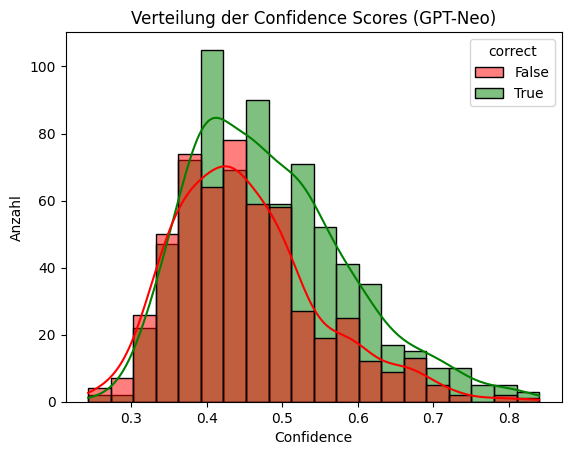

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## subjects

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-07 07:07:17.846500: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751864837.867732   35620 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751864837.874338   35620 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 07:07:17.898327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [03:01<00:00,  7.00it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[530 184]
 [304 249]]

Accuracy:  0.6148382004735596
Precision: 0.6354916067146283  (bezogen auf 'True')
Recall:    0.742296918767507  (bezogen auf 'True')
F1 Score:  0.6847545219638242  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.58      0.45      0.51       553
       False       0.64      0.74      0.68       714

    accuracy                           0.61      1267
   macro avg       0.61      0.60      0.59      1267
weighted avg       0.61      0.61      0.61      1267



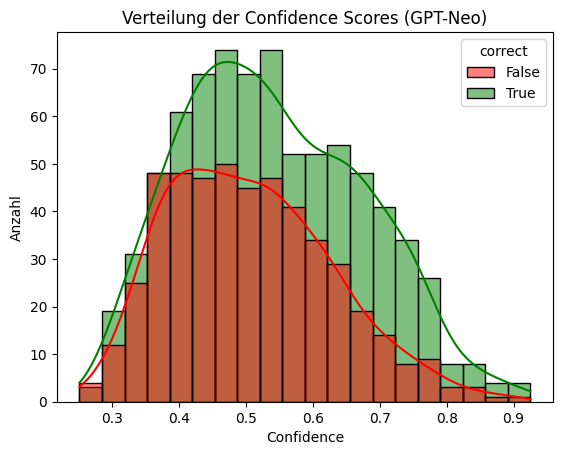

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## extern subject classification

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are a fact-checking assistant.\n"
        f"Task: Determine if the following statement is factually correct.\n"
        f"Use the given subject(s) to guide your decision. These subjects were provided by human annotators: {subjects}.\n"
        f"Respond with a single word only: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Subjects: {subjects}\n"
        f"Answer:"
    )

# Modelle
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-07 07:22:43.358971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751865763.380999   36672 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751865763.387709   36672 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 07:22:43.411904: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [03:10<00:00,  6.66it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects       domain  \
0                                

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[630  84]
 [416 137]]

Accuracy:  0.6053670086819258
Precision: 0.6022944550669216  (bezogen auf 'True')
Recall:    0.8823529411764706  (bezogen auf 'True')
F1 Score:  0.7159090909090909  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.62      0.25      0.35       553
       False       0.60      0.88      0.72       714

    accuracy                           0.61      1267
   macro avg       0.61      0.57      0.53      1267
weighted avg       0.61      0.61      0.56      1267



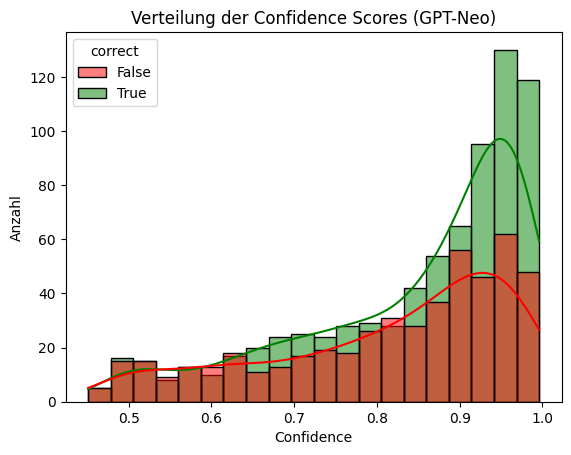

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## tone classification

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # Ladebalken

# Device
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt mit Statement + Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    # weitere Modelle ggf. hinzufügen
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Token-IDs für " True" und " False" (mit Leerzeichen)
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        for statement, tone in tqdm(zip(statements, tones), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)
            
# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Confidence nur für causal-Modell
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe
print(df.head())


2025-07-02 11:08:16.821281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751447296.842515   15239 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751447296.849036   15239 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 11:08:16.873586: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🔄 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:42<00:00,  7.82it/s]

        label                                          statement  \
0        true  Building a wall on the U.S . Mexico border wil...   
1       false  Wisconsin is on pace to double the number of l...   
2       false  Says John McCain has done nothing to help the ...   
3   half-true  Suzanne Bonamici supports a plan that will cut...   
4  pants-fire  When asked by a reporter whether hes at the ce...   

                                            subjects       domain        tone  \
0                                        immigration  immigration     neutral   
1                                               jobs     business  subjective   
2                    military,veterans,voting-record     politics  subjective   
3  medicare,message-machine-2012,campaign-adverti...       health  subjective   
4  campaign-finance,legal-issues,campaign-adverti...     politics     neutral   

  label_Llama-3.1-8B-Instruct  confidence_Llama-3.1-8B-Instruct  
0                        True         

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[602 112]
 [376 177]]

Accuracy:  0.6148382004735596
Precision: 0.6155419222903885  (bezogen auf 'True')
Recall:    0.8431372549019608  (bezogen auf 'True')
F1 Score:  0.7115839243498818  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.61      0.32      0.42       553
       False       0.62      0.84      0.71       714

    accuracy                           0.61      1267
   macro avg       0.61      0.58      0.57      1267
weighted avg       0.61      0.61      0.58      1267



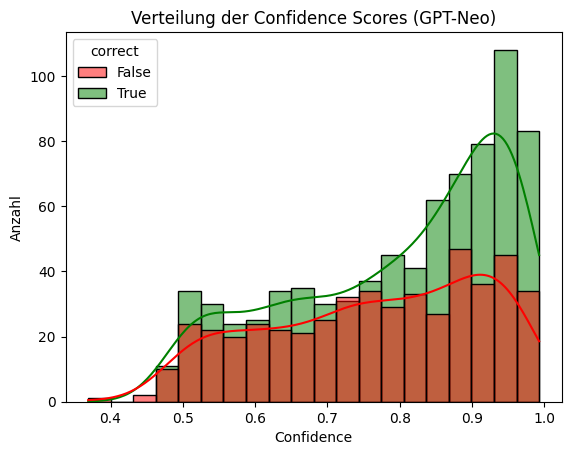

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# GPT-Neo

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "EleutherAI/gpt-neo-2.7B": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: EleutherAI/gpt-neo-2.7B (causal)


2025-07-02 11:16:33.416666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751447793.434558   15832 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751447793.441056   15832 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 11:16:33.466967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
🔍 Verarbeitung: 100%|██████████| 1267/1267 [01:02<00:00, 20.27it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_gpt-neo-2.7B,confidence_gpt-neo-2.7B
0,true,Building a wall on the U.S . Mexico border wil...,immigration,False,0.331986
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.357549
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",True,0.242078
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",True,0.368225
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.280058
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.270634
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.260966
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False,0.352118
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.257779


In [3]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_gpt-neo-2.7B"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[415 299]
 [321 232]]

Accuracy:  0.510655090765588
Precision: 0.563858695652174  (bezogen auf 'True')
Recall:    0.5812324929971989  (bezogen auf 'True')
F1 Score:  0.5724137931034483  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.44      0.42      0.43       553
       False       0.56      0.58      0.57       714

    accuracy                           0.51      1267
   macro avg       0.50      0.50      0.50      1267
weighted avg       0.51      0.51      0.51      1267



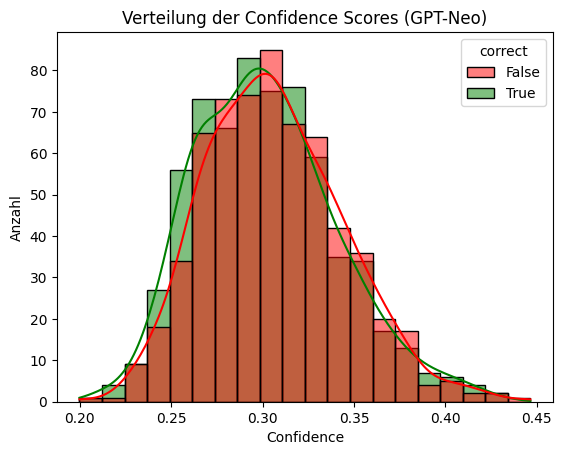

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_gpt-neo-2.7B"]

sns.histplot(data=df, x="confidence_gpt-neo-2.7B", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## subjects

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "EleutherAI/gpt-neo-2.7B": "causal"
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-02 11:20:04.873403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751448004.894840   16441 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751448004.901419   16441 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 11:20:04.925856: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Lade Modell: EleutherAI/gpt-neo-2.7B (causal)


Processing causal model: 100%|██████████| 1267/1267 [01:21<00:00, 15.64it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects label_gpt-neo-2.7B  \
0                          

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_gpt-neo-2.7B"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[665  49]
 [512  41]]

Accuracy:  0.5572217837411207
Precision: 0.5649957519116398  (bezogen auf 'True')
Recall:    0.9313725490196079  (bezogen auf 'True')
F1 Score:  0.7033315705975675  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.46      0.07      0.13       553
       False       0.56      0.93      0.70       714

    accuracy                           0.56      1267
   macro avg       0.51      0.50      0.42      1267
weighted avg       0.52      0.56      0.45      1267



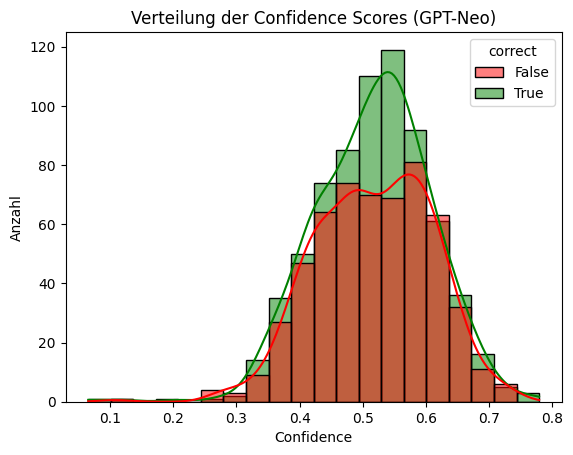

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_gpt-neo-2.7B"]

sns.histplot(data=df, x="confidence_gpt-neo-2.7B", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## extern subject classification

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are a fact-checking assistant.\n"
        f"Task: Determine if the following statement is factually correct.\n"
        f"Use the given subject(s) to guide your decision. These subjects were provided by human annotators: {subjects}.\n"
        f"Respond with a single word only: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Subjects: {subjects}\n"
        f"Answer:"
    )

# Modelle
models = {
     "EleutherAI/gpt-neo-2.7B": "causal"
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-07 07:27:17.976256: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751866037.998472   37025 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751866038.005244   37025 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 07:27:18.029397: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Lade Modell: EleutherAI/gpt-neo-2.7B (causal)


Processing causal model: 100%|██████████| 1267/1267 [01:26<00:00, 14.56it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects       domain  \
0                                

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_gpt-neo-2.7B"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[710   4]
 [551   2]]

Accuracy:  0.5619573796369376
Precision: 0.56304520222046  (bezogen auf 'True')
Recall:    0.9943977591036415  (bezogen auf 'True')
F1 Score:  0.7189873417721518  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.33      0.00      0.01       553
       False       0.56      0.99      0.72       714

    accuracy                           0.56      1267
   macro avg       0.45      0.50      0.36      1267
weighted avg       0.46      0.56      0.41      1267



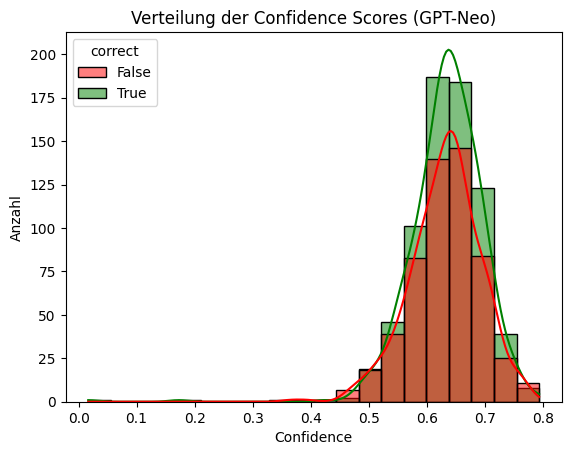

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_gpt-neo-2.7B"]

sns.histplot(data=df, x="confidence_gpt-neo-2.7B", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## tone classification

In [7]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # Ladebalken

# Device
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt mit Statement + Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
     "EleutherAI/gpt-neo-2.7B": "causal"
    # weitere Modelle ggf. hinzufügen
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Token-IDs für " True" und " False" (mit Leerzeichen)
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        for statement, tone in tqdm(zip(statements, tones), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)
            
# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Confidence nur für causal-Modell
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe
print(df.head())


🔄 Lade Modell: EleutherAI/gpt-neo-2.7B (causal)


Processing causal model: 100%|██████████| 1267/1267 [01:16<00:00, 16.49it/s]

        label                                          statement  \
0        true  Building a wall on the U.S . Mexico border wil...   
1       false  Wisconsin is on pace to double the number of l...   
2       false  Says John McCain has done nothing to help the ...   
3   half-true  Suzanne Bonamici supports a plan that will cut...   
4  pants-fire  When asked by a reporter whether hes at the ce...   

                                            subjects       domain        tone  \
0                                        immigration  immigration     neutral   
1                                               jobs     business  subjective   
2                    military,veterans,voting-record     politics  subjective   
3  medicare,message-machine-2012,campaign-adverti...       health  subjective   
4  campaign-finance,legal-issues,campaign-adverti...     politics     neutral   

  label_gpt-neo-2.7B  confidence_gpt-neo-2.7B  
0               True                 0.579418  
1       

In [10]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_gpt-neo-2.7B"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[687  27]
 [528  25]]

Accuracy:  0.5619573796369376
Precision: 0.5654320987654321  (bezogen auf 'True')
Recall:    0.9621848739495799  (bezogen auf 'True')
F1 Score:  0.7122861586314152  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.05      0.08       553
       False       0.57      0.96      0.71       714

    accuracy                           0.56      1267
   macro avg       0.52      0.50      0.40      1267
weighted avg       0.53      0.56      0.44      1267



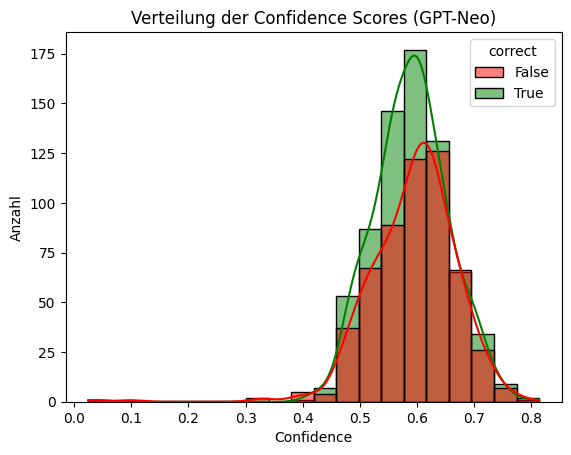

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_gpt-neo-2.7B"]

sns.histplot(data=df, x="confidence_gpt-neo-2.7B", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# DeepSeek

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "deepseek-ai/deepseek-llm-7b-base": "causal",
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df


📦 Lade Modell: deepseek-ai/deepseek-llm-7b-base (causal)


2025-07-02 11:57:22.876622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751450242.892355   17915 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751450242.897143   17915 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 11:57:22.916408: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [01:48<00:00, 11.66it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_deepseek-llm-7b-base,confidence_deepseek-llm-7b-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,False,0.295238
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.225207
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.322400
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.364065
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,0.272826
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,False,0.274074
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",False,0.279448
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False,0.252576
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False,0.244082


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_deepseek-llm-7b-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[212 502]
 [ 93 460]]

Accuracy:  0.5303867403314917
Precision: 0.6950819672131148  (bezogen auf 'True')
Recall:    0.2969187675070028  (bezogen auf 'True')
F1 Score:  0.41609421000981356  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.83      0.61       553
       False       0.70      0.30      0.42       714

    accuracy                           0.53      1267
   macro avg       0.59      0.56      0.51      1267
weighted avg       0.60      0.53      0.50      1267



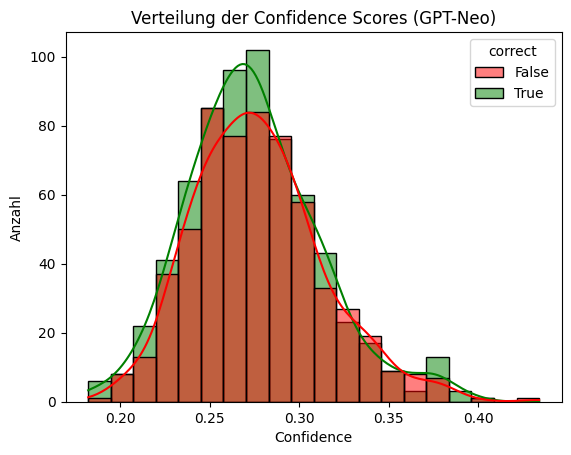

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_deepseek-llm-7b-base"]

sns.histplot(data=df, x="confidence_deepseek-llm-7b-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## subjects

In [2]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "deepseek-ai/deepseek-llm-7b-base": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


Lade Modell: deepseek-ai/deepseek-llm-7b-base (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:35<00:00,  8.16it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [3]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_deepseek-llm-7b-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[642  72]
 [464  89]]

Accuracy:  0.5769534333070244
Precision: 0.5804701627486437  (bezogen auf 'True')
Recall:    0.8991596638655462  (bezogen auf 'True')
F1 Score:  0.7054945054945055  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.55      0.16      0.25       553
       False       0.58      0.90      0.71       714

    accuracy                           0.58      1267
   macro avg       0.57      0.53      0.48      1267
weighted avg       0.57      0.58      0.51      1267



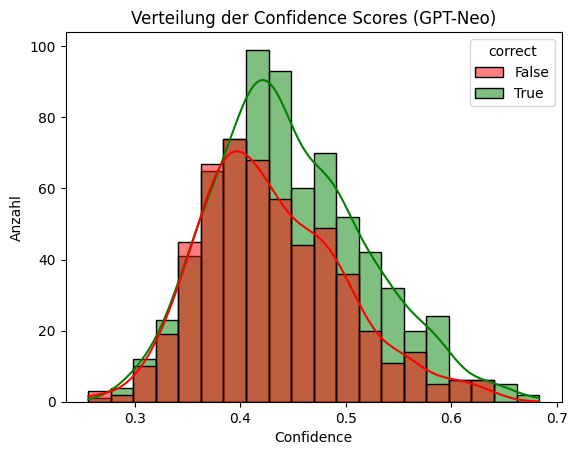

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_deepseek-llm-7b-base"]

sns.histplot(data=df, x="confidence_deepseek-llm-7b-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## extern subject classification

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are a fact-checking assistant.\n"
        f"Task: Determine if the following statement is factually correct.\n"
        f"Use the given subject(s) to guide your decision. These subjects were provided by human annotators: {subjects}.\n"
        f"Respond with a single word only: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Subjects: {subjects}\n"
        f"Answer:"
    )

# Modelle
models = {
    "deepseek-ai/deepseek-llm-7b-base": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-07 07:30:45.678742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751866245.700551   37778 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751866245.707327   37778 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 07:30:45.731761: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Lade Modell: deepseek-ai/deepseek-llm-7b-base (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:49<00:00,  7.49it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects       domain  \
0                                

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_deepseek-llm-7b-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[691  23]
 [516  37]]

Accuracy:  0.574585635359116
Precision: 0.5724937862468932  (bezogen auf 'True')
Recall:    0.9677871148459384  (bezogen auf 'True')
F1 Score:  0.7194169703279542  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.62      0.07      0.12       553
       False       0.57      0.97      0.72       714

    accuracy                           0.57      1267
   macro avg       0.59      0.52      0.42      1267
weighted avg       0.59      0.57      0.46      1267



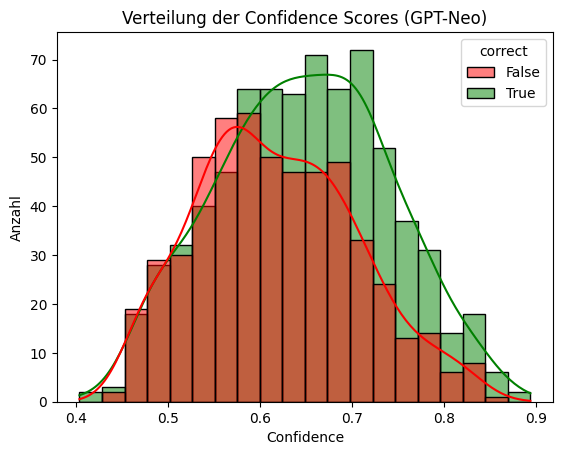

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_deepseek-llm-7b-base"]

sns.histplot(data=df, x="confidence_deepseek-llm-7b-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## tone classification

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # Ladebalken

# Device
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt mit Statement + Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "deepseek-ai/deepseek-llm-7b-base": "causal",
    # weitere Modelle ggf. hinzufügen
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Token-IDs für " True" und " False" (mit Leerzeichen)
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        for statement, tone in tqdm(zip(statements, tones), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)
            
# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Confidence nur für causal-Modell
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe
print(df.head())


2025-07-02 13:08:41.432518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751454521.453900   20707 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751454521.460420   20707 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 13:08:41.485067: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


🔄 Lade Modell: deepseek-ai/deepseek-llm-7b-base (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:14<00:00,  9.40it/s]

        label                                          statement  \
0        true  Building a wall on the U.S . Mexico border wil...   
1       false  Wisconsin is on pace to double the number of l...   
2       false  Says John McCain has done nothing to help the ...   
3   half-true  Suzanne Bonamici supports a plan that will cut...   
4  pants-fire  When asked by a reporter whether hes at the ce...   

                                            subjects       domain        tone  \
0                                        immigration  immigration     neutral   
1                                               jobs     business  subjective   
2                    military,veterans,voting-record     politics  subjective   
3  medicare,message-machine-2012,campaign-adverti...       health  subjective   
4  campaign-finance,legal-issues,campaign-adverti...     politics     neutral   

  label_deepseek-llm-7b-base  confidence_deepseek-llm-7b-base  
0                       True            

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_deepseek-llm-7b-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[712   2]
 [552   1]]

Accuracy:  0.5627466456195738
Precision: 0.5632911392405063  (bezogen auf 'True')
Recall:    0.9971988795518207  (bezogen auf 'True')
F1 Score:  0.7199191102123357  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.33      0.00      0.00       553
       False       0.56      1.00      0.72       714

    accuracy                           0.56      1267
   macro avg       0.45      0.50      0.36      1267
weighted avg       0.46      0.56      0.41      1267



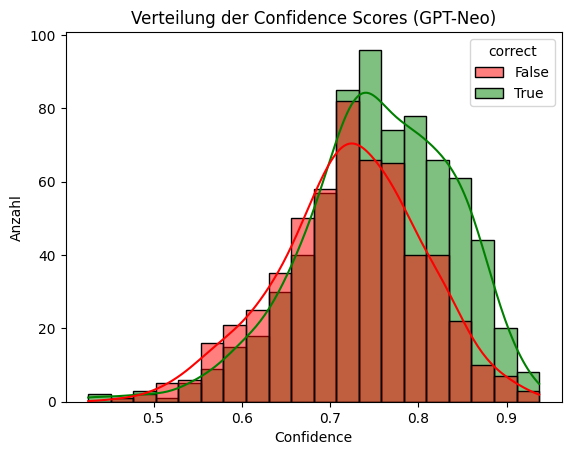

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_deepseek-llm-7b-base"]

sns.histplot(data=df, x="confidence_deepseek-llm-7b-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# Flan-T5

In [4]:
import torch
import os
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
)

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Anpassen bei mehreren GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Vorlage
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modelle definieren
models = {
    "google/flan-t5-base": "seq2seq"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    if model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
        model.eval()

        for text in tqdm(statements, desc=f"🔍 Verarbeitung {model_name}"):
            prompt = build_prompt(text)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    max_new_tokens=1,
                    return_dict_in_generate=True,
                    output_scores=True
                )

            generated_token_id = output.sequences[0, -1].item()
            logits = output.scores[0][0]
            probs = F.softmax(logits, dim=-1)
            confidence = probs[generated_token_id].item()

            decoded = tokenizer.decode([generated_token_id], skip_special_tokens=True).strip()
            results[model_name].append(decoded)
            confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: google/flan-t5-base (seq2seq)


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.
🔍 Verarbeitung google/flan-t5-base: 100%|██████████| 1267/1267 [00:33<00:00, 37.71it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_flan-t5-base,confidence_flan-t5-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.597664
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.578471
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",Fal,0.500962
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",Fal,0.584636
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.566470
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,Fal,0.656822
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",Fal,0.501022
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.540148
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.508772


In [5]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_flan-t5-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[439 275]
 [317 236]]

Accuracy:  0.5327545382794001
Precision: 0.5806878306878307  (bezogen auf 'True')
Recall:    0.6148459383753502  (bezogen auf 'True')
F1 Score:  0.5972789115646259  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.46      0.43      0.44       553
       False       0.58      0.61      0.60       714

    accuracy                           0.53      1267
   macro avg       0.52      0.52      0.52      1267
weighted avg       0.53      0.53      0.53      1267



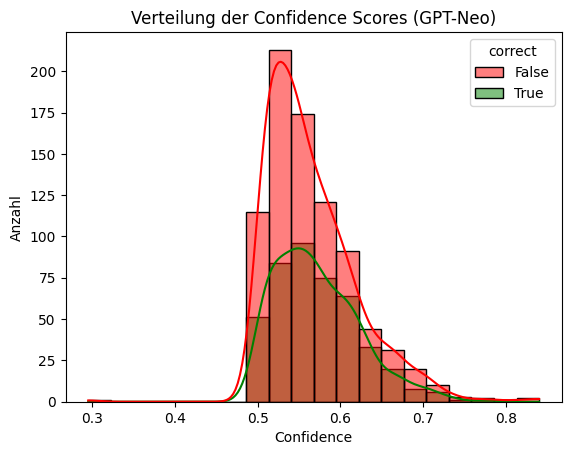

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_flan-t5-base"]

sns.histplot(data=df, x="confidence_flan-t5-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## subjects

In [2]:
import torch
import os
import pandas as pd
from tqdm import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)
import torch.nn.functional as F

# CUDA + bitsandbytes
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # anpassen, wenn nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modellübersicht
models = {
    "google/flan-t5-base": "seq2seq",
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebniscontainer
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modellverarbeitung
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")
    if model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
        model.eval()

        for statement, subj in tqdm(zip(statements, subjects), total=len(statements), desc="🔍 Verarbeitung"):
            prompt = build_prompt(statement, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    max_new_tokens=1,
                    return_dict_in_generate=True,
                    output_scores=True
                )

            generated_token_id = output.sequences[0, -1].item()
            score = output.scores[0][0, generated_token_id]
            confidence = F.softmax(output.scores[0][0], dim=-1)[generated_token_id].item()

            decoded = tokenizer.decode([generated_token_id], skip_special_tokens=True).strip()
            results[model_name].append(decoded)
            confidences[model_name].append(confidence)

# Ergebnisse einfügen
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: google/flan-t5-base (seq2seq)


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.
🔍 Verarbeitung: 100%|██████████| 1267/1267 [00:34<00:00, 36.84it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_flan-t5-base,confidence_flan-t5-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.932773
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.919755
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",True,0.929508
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",True,0.852041
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.857628
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.773002
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.872244
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.868687
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.886639


In [3]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_flan-t5-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[711   3]
 [552   1]]

Accuracy:  0.5619573796369376
Precision: 0.5629453681710214  (bezogen auf 'True')
Recall:    0.9957983193277311  (bezogen auf 'True')
F1 Score:  0.7192716236722306  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.25      0.00      0.00       553
       False       0.56      1.00      0.72       714

    accuracy                           0.56      1267
   macro avg       0.41      0.50      0.36      1267
weighted avg       0.43      0.56      0.41      1267



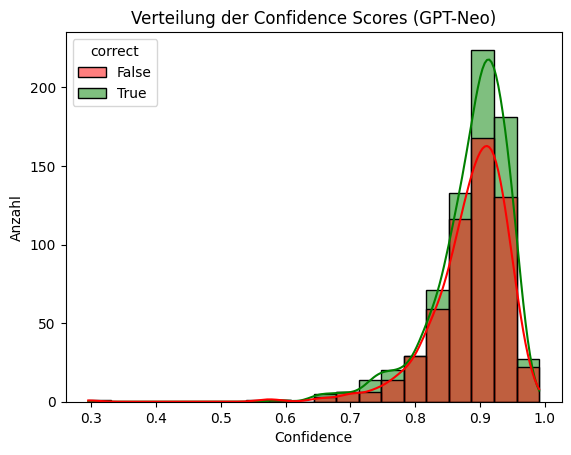

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_flan-t5-base"]

sns.histplot(data=df, x="confidence_flan-t5-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## extern subject classification

In [1]:
import torch
import os
import pandas as pd
from tqdm import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)
import torch.nn.functional as F

# CUDA + bitsandbytes
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen, wenn nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are a fact-checking assistant.\n"
        f"Task: Determine if the following statement is factually correct.\n"
        f"Use the given subject(s) to guide your decision. These subjects were provided by human annotators: {subjects}.\n"
        f"Respond with a single word only: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Subjects: {subjects}\n"
        f"Answer:"
    )

# Modellübersicht
models = {
    "google/flan-t5-base": "seq2seq",
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebniscontainer
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modellverarbeitung
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")
    if model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
        model.eval()

        for statement, subj in tqdm(zip(statements, subjects), total=len(statements), desc="🔍 Verarbeitung"):
            prompt = build_prompt(statement, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    max_new_tokens=1,
                    return_dict_in_generate=True,
                    output_scores=True
                )

            generated_token_id = output.sequences[0, -1].item()
            score = output.scores[0][0, generated_token_id]
            confidence = F.softmax(output.scores[0][0], dim=-1)[generated_token_id].item()

            decoded = tokenizer.decode([generated_token_id], skip_special_tokens=True).strip()
            results[model_name].append(decoded)
            confidences[model_name].append(confidence)

# Ergebnisse einfügen
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

print("\n✅ Verarbeitung abgeschlossen.")
df


2025-07-07 07:34:19.879470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751866459.901385   38104 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751866459.908158   38104 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 07:34:19.932044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



📦 Lade Modell: google/flan-t5-base (seq2seq)


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.
🔍 Verarbeitung: 100%|██████████| 1267/1267 [00:37<00:00, 33.64it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,domain,label_flan-t5-base,confidence_flan-t5-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,True,0.832710
1,false,Wisconsin is on pace to double the number of l...,jobs,business,True,0.839630
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,True,0.818901
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,True,0.865949
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,True,0.842682
...,...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,True,0.801092
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,Fal,0.502752
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,True,0.804236
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,True,0.819960


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_flan-t5-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[692  22]
 [526  27]]

Accuracy:  0.5674822415153907
Precision: 0.5681444991789819  (bezogen auf 'True')
Recall:    0.969187675070028  (bezogen auf 'True')
F1 Score:  0.7163561076604554  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.55      0.05      0.09       553
       False       0.57      0.97      0.72       714

    accuracy                           0.57      1267
   macro avg       0.56      0.51      0.40      1267
weighted avg       0.56      0.57      0.44      1267



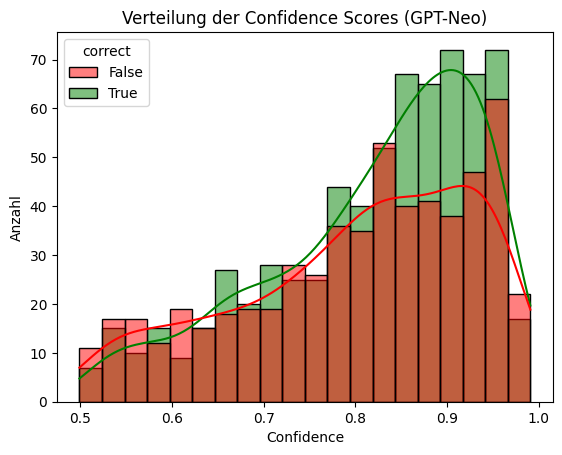

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_flan-t5-base"]

sns.histplot(data=df, x="confidence_flan-t5-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## tone classification

In [9]:
import torch
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # anpassen, wenn nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt nur mit Statement und Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modell(e)
models = {
    "google/flan-t5-base": "seq2seq"
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse vorbereiten
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
        model.eval()

        for statement, tone in tqdm(zip(statements, tones), total=len(statements), desc=f"🔍 Verarbeitung {model_name}"):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(
                    **inputs,
                    max_new_tokens=1,
                    return_dict_in_generate=True,
                    output_scores=True,
                )
            generated_token_id = output.sequences[0, -1].item()
            logits = output.scores[0][0]
            probs = F.softmax(logits, dim=-1)
            confidence = probs[generated_token_id].item()

            decoded = tokenizer.decode([generated_token_id], skip_special_tokens=True).strip()
            results[model_name].append(decoded)
            confidences[model_name].append(confidence)

# Ergebnisse anhängen
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Speichern
# df.to_csv("statements_with_predictions.csv", index=False)
# print("✅ Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df


🔄 Lade Modell: google/flan-t5-base (seq2seq)


🔍 Verarbeitung google/flan-t5-base: 100%|██████████| 1267/1267 [00:34<00:00, 37.19it/s]


,label,statement,subjects,domain,tone,label_flan-t5-base,confidence_flan-t5-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,neutral,Fal,0.527727
1,false,Wisconsin is on pace to double the number of l...,jobs,business,subjective,Fal,0.585285
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,subjective,Fal,0.722356
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,subjective,Fal,0.723771
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,neutral,Fal,0.611008
...,...,...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,neutral,Fal,0.773291
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,neutral,Fal,0.655846
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,neutral,Fal,0.547908
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,neutral,Fal,0.632046


In [10]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_flan-t5-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[ 49 665]
 [ 36 517]]

Accuracy:  0.44672454617206
Precision: 0.5764705882352941  (bezogen auf 'True')
Recall:    0.06862745098039216  (bezogen auf 'True')
F1 Score:  0.12265331664580725  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.44      0.93      0.60       553
       False       0.58      0.07      0.12       714

    accuracy                           0.45      1267
   macro avg       0.51      0.50      0.36      1267
weighted avg       0.52      0.45      0.33      1267



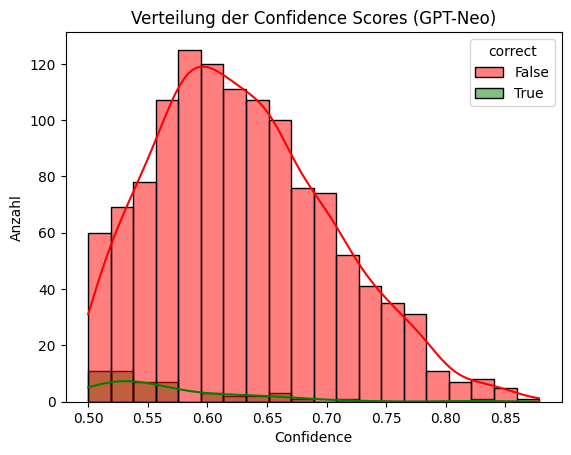

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_flan-t5-base"]

sns.histplot(data=df, x="confidence_flan-t5-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# Gemma

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "google/gemma-2b-it": "causal",
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: google/gemma-2b-it (causal)


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2b-it.
401 Client Error. (Request ID: Root=1-6865168b-63802d5f08b829110ccad4f6;07907997-366c-4eff-b398-3176908edffa)

Cannot access gated repo for url https://huggingface.co/google/gemma-2b-it/resolve/main/config.json.
Access to model google/gemma-2b-it is restricted. You must have access to it and be authenticated to access it. Please log in.

In [6]:
def clean_label(val):
    val = str(val).strip().lower().replace(".", "")
    if val == "true":
        return "True"
    elif val == "false":
        return "False"
    else:
        return "True"

df["label_gemma-2b-it"] = df["label_gemma-2b-it"].apply(clean_label)

In [7]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_gemma-2b-it"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[159 555]
 [ 89 464]]
Accuracy: 0.49171270718232046
Precision: 0.5482387065117604
Recall: 0.5308743750664823
F1-Score: 0.4604460596827009
              precision    recall  f1-score   support

        True       0.64      0.22      0.33       714
       False       0.46      0.84      0.59       553

    accuracy                           0.49      1267
   macro avg       0.55      0.53      0.46      1267
weighted avg       0.56      0.49      0.44      1267



## subjects

In [1]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Liste der Modelle mit ihrer Architektur
models = {
    #"meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    "google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"Datasets/LIAR/preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse Container
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip())

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for text in statements:  # Roberta verwendet nur das statement
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse im DataFrame speichern
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Export
#df.to_csv("statements_with_predictions_T5.csv", index=False)
#print("Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df

c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lade Modell: google/gemma-2b-it (causal)


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.74s/it]
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


,label,statement,subjects,label_gemma-2b-it
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True
1,false,Wisconsin is on pace to double the number of l...,jobs,True
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",True
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True
...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True


In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_gemma-2b-it"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[657  57]
 [495  58]]
Accuracy: 0.5643251775848461
Precision: 0.5373301630434782
Recall: 0.5125252632698649
F1-Score: 0.43891637945973005
              precision    recall  f1-score   support

        True       0.57      0.92      0.70       714
       False       0.50      0.10      0.17       553

    accuracy                           0.56      1267
   macro avg       0.54      0.51      0.44      1267
weighted avg       0.54      0.56      0.47      1267



## extern subject classification

In [4]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are a fact-checking assistant.\n"
        f"Task: Determine if the following statement is factually correct.\n"
        f"Use the given subject(s) to guide your decision. These subjects were provided by human annotators: {subjects}.\n"
        f"Respond with a single word only: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Subjects: {subjects}\n"
        f"Answer:"
    )

# Liste der Modelle mit ihrer Architektur
models = {
    #"meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    "google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["domain"].tolist()

# Ergebnisse Container
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip())

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for text in statements:  # Roberta verwendet nur das statement
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse im DataFrame speichern
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Export
#df.to_csv("statements_with_predictions_T5.csv", index=False)
#print("Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df

Lade Modell: google/gemma-2b-it (causal)


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2b-it.
401 Client Error. (Request ID: Root=1-686b5cb2-0376dd974918e0f3269f101b;95340b70-608d-49f0-9b82-554f559c5ae7)

Cannot access gated repo for url https://huggingface.co/google/gemma-2b-it/resolve/main/config.json.
Access to model google/gemma-2b-it is restricted. You must have access to it and be authenticated to access it. Please log in.

In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_gemma-2b-it"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[670  43]
 [507  46]]
Accuracy: 0.5651144435674822
Precision: 0.36203259095204915
Recall: 0.34051933009490715
F1-Score: 0.2839739861935506
              precision    recall  f1-score   support

        True       0.57      0.94      0.71       714
       False       0.52      0.08      0.14       553

   micro avg       0.57      0.57      0.57      1267
   macro avg       0.54      0.51      0.43      1267
weighted avg       0.55      0.57      0.46      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## tone classification

In [ ]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Domain (falls relevant)
def build_prompt(statement, subjects):
    return (
        f"Classify the tone of the following statement. "
        f"Choose one of: neutral, subjective, ironic, or emotional.\n\n"
        f"Statement: \"{statement}\"\n"
        f"Tone:"
    )

# Modelle und Typen
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    #"google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["domain"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}

# Durchlauf für jedes Modell
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=10)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            # Entfernt Prompt + nur Neutralen Text behalten
            result = decoded.split("Neutral:")[-1].strip()
            results[model_name].append(result)
            
# Ergebnisse in DataFrame einfügen
for model_name in results:
    df[f"tone"] = results[model_name]

# Export
output_path = "statements_tone.csv"
df.to_csv(output_path, index=False)
print(f"✅ Fertig – Ergebnisse gespeichert in '{output_path}'")


c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.87s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Set

✅ Fertig – Ergebnisse gespeichert in 'statements_tone.csv'


In [ ]:
df= pd.read_csv("statements_tone.csv")


import re

def extract_tone(text):
    if pd.isna(text):
        return ""
    # Suche nach dem ersten Vorkommen des Ton-Worts nach 'Tone:'
    match = re.search(r'Tone:\s*([a-zA-Z-]+)', str(text))
    if match:
        return match.group(1).strip().lower()
    # Falls das nicht klappt, suche allgemein im Text
    match2 = re.search(r'\b(neutral|subjective|ironic|emotional)\b', str(text).lower())
    return match2.group(1) if match2 else ""

df["tone"] = df["tone"].apply(extract_tone)

df.to_csv("statements_tone_cleaned.csv", index=False)

In [3]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt nur mit Statement und Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modell(e)
models = {
    #"meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    "google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse vorbereiten
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto"
        )

        for statement, tone in zip(statements, tones):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto"
        )

        for statement, tone in zip(statements, tones):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip().split()[0])

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for statement in statements:
            inputs = tokenizer(statement, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse anhängen
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Speichern
#df.to_csv("statements_with_predictions.csv", index=False)
#print("✅ Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df


🔄 Lade Modell: google/gemma-2b-it (causal)


Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.38s/it]
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,label,statement,subjects,domain,tone,label_gemma-2b-it
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,neutral,True
1,false,Wisconsin is on pace to double the number of l...,jobs,business,subjective,True
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,subjective,False
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,subjective,False
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,neutral,True
...,...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,neutral,True
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,neutral,True
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,neutral,True
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,neutral,True


In [4]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_gemma-2b-it"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[590 123]
 [430 122]]
Accuracy: 0.5619573796369376
Precision: 0.26909763905562223
Recall: 0.2617363401056625
F1-Score: 0.24656797703601563
              precision    recall  f1-score   support

        True       0.58      0.83      0.68       714
       False       0.50      0.22      0.31       553

   micro avg       0.56      0.56      0.56      1267
   macro avg       0.54      0.52      0.49      1267
weighted avg       0.54      0.56      0.52      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Roberta

In [3]:
import torch
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # anpassen, wenn nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Dein Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Liste der Modelle mit ihrer Architektur
models = {
    "roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")  # Achtung: \t statt Tabulatorzeichen als String
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
        model.eval()

        for text in tqdm(statements, desc=f"Verarbeitung {model_name}"):
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                probs = F.softmax(logits, dim=-1)
                confidence, pred = torch.max(probs, dim=-1)
                pred_label = "True" if pred.item() == 1 else "False"

            results[model_name].append(pred_label)
            confidences[model_name].append(confidence.item())

# Ergebnisse in DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]


df


Lade Modell: roberta-base (roberta)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Verarbeitung roberta-base: 100%|██████████| 1267/1267 [00:08<00:00, 144.47it/s]


,label,statement,subjects,label_roberta-base,confidence_roberta-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.552411
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.554598
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",True,0.555085
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",True,0.553828
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.554652
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.553100
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.553292
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.553348
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.553846


In [4]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_roberta-base"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[714   0]
 [553   0]]

Accuracy:  0.56353591160221
Precision: 0.56353591160221  (bezogen auf 'True')
Recall:    1.0  (bezogen auf 'True')
F1 Score:  0.7208480565371025  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.00      0.00      0.00       553
       False       0.56      1.00      0.72       714

    accuracy                           0.56      1267
   macro avg       0.28      0.50      0.36      1267
weighted avg       0.32      0.56      0.41      1267



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


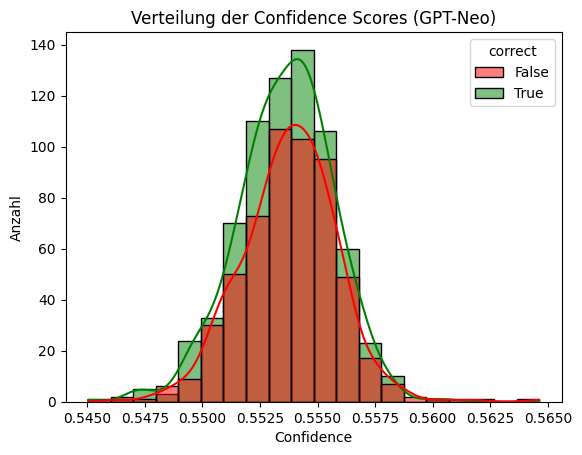

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_roberta-base"]

sns.histplot(data=df, x="confidence_roberta-base", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## subjects

In [4]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Liste der Modelle mit ihrer Architektur
models = {
    #"meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    #"google/gemma-2b-it": "causal",
    "roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"Datasets/LIAR/preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse Container
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip())

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for text in statements:  # Roberta verwendet nur das statement
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse im DataFrame speichern
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Export
#df.to_csv("statements_with_predictions_T5.csv", index=False)
#print("Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df

Lade Modell: roberta-base (roberta)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,label,statement,subjects,label_roberta-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,False
1,false,Wisconsin is on pace to double the number of l...,jobs,False
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False
...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,False
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",False
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False


In [5]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_roberta-base"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[  0 714]
 [  0 553]]
Accuracy: 0.43646408839779005
Precision: 0.21823204419889503
Recall: 0.5
F1-Score: 0.3038461538461538
              precision    recall  f1-score   support

        True       0.00      0.00      0.00       714
       False       0.44      1.00      0.61       553

    accuracy                           0.44      1267
   macro avg       0.22      0.50      0.30      1267
weighted avg       0.19      0.44      0.27      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

## extern subject classification

In [1]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"You are a fact-checking assistant.\n"
        f"Task: Determine if the following statement is factually correct.\n"
        f"Use the given subject(s) to guide your decision. These subjects were provided by human annotators: {subjects}.\n"
        f"Respond with a single word only: True or False.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Subjects: {subjects}\n"
        f"Answer:"
    )

# Liste der Modelle mit ihrer Architektur
models = {
    "roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["domain"].tolist()

# Ergebnisse Container
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip())

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for text in statements:  # Roberta verwendet nur das statement
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse im DataFrame speichern
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Export
#df.to_csv("statements_with_predictions_T5.csv", index=False)
#print("Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df

2025-07-07 07:36:18.530787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751866578.552703   38354 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751866578.559388   38354 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 07:36:18.583151: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Lade Modell: roberta-base (roberta)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,label,statement,subjects,domain,label_roberta-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,True
1,false,Wisconsin is on pace to double the number of l...,jobs,business,True
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,True
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,True
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,True
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,True
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,True
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,True
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,True


In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_roberta-base"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[670  44]
 [525  28]]
Accuracy: 0.5509076558800315
Precision: 0.47477917247791723
Recall: 0.49450413076623057
F1-Score: 0.3957690937663698
              precision    recall  f1-score   support

        True       0.56      0.94      0.70       714
       False       0.39      0.05      0.09       553

    accuracy                           0.55      1267
   macro avg       0.47      0.49      0.40      1267
weighted avg       0.49      0.55      0.43      1267



## tone classification

In [ ]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt-Template mit Statement + Domain (falls relevant)
def build_prompt(statement, subjects):
    return (
        f"Classify the tone of the following statement. "
        f"Choose one of: neutral, subjective, ironic, or emotional.\n\n"
        f"Statement: \"{statement}\"\n"
        f"Tone:"
    )

# Modelle und Typen
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    #"google/gemma-2b-it": "causal",
    #"roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_with_domain.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["domain"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}

# Durchlauf für jedes Modell
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")

        for text, subj in zip(statements, subjects):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=10)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            # Entfernt Prompt + nur Neutralen Text behalten
            result = decoded.split("Neutral:")[-1].strip()
            results[model_name].append(result)
            
# Ergebnisse in DataFrame einfügen
for model_name in results:
    df[f"tone"] = results[model_name]

# Export
output_path = "statements_tone.csv"
df.to_csv(output_path, index=False)
print(f"✅ Fertig – Ergebnisse gespeichert in '{output_path}'")


c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.87s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\bitsandbytes\nn\modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Set

✅ Fertig – Ergebnisse gespeichert in 'statements_tone.csv'


In [ ]:
df= pd.read_csv("statements_tone.csv")


import re

def extract_tone(text):
    if pd.isna(text):
        return ""
    # Suche nach dem ersten Vorkommen des Ton-Worts nach 'Tone:'
    match = re.search(r'Tone:\s*([a-zA-Z-]+)', str(text))
    if match:
        return match.group(1).strip().lower()
    # Falls das nicht klappt, suche allgemein im Text
    match2 = re.search(r'\b(neutral|subjective|ironic|emotional)\b', str(text).lower())
    return match2.group(1) if match2 else ""

df["tone"] = df["tone"].apply(extract_tone)

df.to_csv("statements_tone_cleaned.csv", index=False)

In [8]:
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BitsAndBytesConfig,
)

# CUDA + bitsandbytes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

# Prompt nur mit Statement und Tone
def build_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking factual statements.\n"
        f"Your task is to determine whether the following statement is factually correct.\n"
        f"Respond strictly with one word: True or False.\n"
        f"The tone of the statement is: {tone}.\n\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Answer: False\n\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modell(e)
models = {
    #"meta-llama/Llama-3.1-8B-Instruct": "causal",
    #"EleutherAI/gpt-neo-2.7B": "causal",
    #"deepseek-ai/deepseek-llm-7b-base": "causal",
    #"google/flan-t5-base": "seq2seq",
    #"google/gemma-2b-it": "causal",
    "roberta-base": "roberta"
}

# Daten laden
df = pd.read_csv("statements_tone_cleaned.csv")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
tones = df["tone"].tolist()

# Ergebnisse vorbereiten
results = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"🔄 Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto"
        )

        for statement, tone in zip(statements, tones):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            result = decoded.split("Answer:")[-1].strip().split()[0]
            results[model_name].append(result)

    elif model_type == "seq2seq":
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name, quantization_config=bnb_config, device_map="auto"
        )

        for statement, tone in zip(statements, tones):
            prompt = build_prompt(statement, tone)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=5)
            decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            results[model_name].append(decoded.strip().split()[0])

    elif model_type == "roberta":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

        for statement in statements:
            inputs = tokenizer(statement, return_tensors="pt", truncation=True, padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                pred = torch.argmax(logits, dim=-1).item()
            results[model_name].append("True" if pred == 1 else "False")

# Ergebnisse anhängen
for model_name in results:
    df[f"label_{model_name.split('/')[-1]}"] = results[model_name]

# Speichern
#df.to_csv("statements_with_predictions.csv", index=False)
#print("✅ Fertig – Ergebnisse gespeichert in 'statements_with_predictions.csv'")
df


🔄 Lade Modell: roberta-base (roberta)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,label,statement,subjects,domain,tone,label_roberta-base
0,true,Building a wall on the U.S . Mexico border wil...,immigration,immigration,neutral,False
1,false,Wisconsin is on pace to double the number of l...,jobs,business,subjective,False
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,subjective,False
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",health,subjective,False
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,neutral,False
...,...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,education,neutral,False
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",environment,neutral,False
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",politics,neutral,False
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",politics,neutral,False


In [9]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Standardwert

# Ground Truth und Prediction binär mappen
y_true = df["label"].apply(map_label)
y_pred = df["label_roberta-base"].astype(str).str.strip().str.capitalize()

# Wahrheits-/Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

# Metriken
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro", pos_label=None))
print("Recall:", recall_score(y_true, y_pred, average="macro"))
print("F1-Score:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, labels=["True", "False"]))

Confusion Matrix (True/False):
[[  0 714]
 [  0 553]]
Accuracy: 0.43646408839779005
Precision: 0.21823204419889503
Recall: 0.5
F1-Score: 0.3038461538461538
              precision    recall  f1-score   support

        True       0.00      0.00      0.00       714
       False       0.44      1.00      0.61       553

    accuracy                           0.44      1267
   macro avg       0.22      0.50      0.30      1267
weighted avg       0.19      0.44      0.27      1267



c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lukas\miniconda3\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c